# CIFAR-10 Image Classification using Convolutional Neural Networks (CNN)

**A Complete, Production-Quality Deep Learning Pipeline built with TensorFlow / Keras**

---

## Project Description

This notebook implements an end-to-end image classification system for the **CIFAR-10** dataset using a
**Convolutional Neural Network (CNN)** built with the TensorFlow `tf.keras` Functional API. It covers every
stage of a real-world deep learning workflow: data loading, exploratory data analysis (EDA), preprocessing,
model design, training with callbacks, evaluation, visualization, error analysis, and model persistence.

## Objective

- Build a CNN capable of classifying 32x32 color images into 10 mutually exclusive categories.
- Achieve strong generalization performance using regularization techniques (Batch Normalization, Dropout).
- Demonstrate a clean, efficient, reproducible, and memory-conscious deep learning pipeline suitable for
  Google Colab's free GPU tier.

## Dataset Description

The **CIFAR-10** dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class.
There are 50,000 training images and 10,000 test images. The dataset is automatically downloaded via
`tensorflow.keras.datasets.cifar10`, so no manual download is required.

**Classes:** Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

## Why CNN for Image Classification?

Convolutional Neural Networks are the standard architecture for image classification because:

- **Local connectivity**: Convolutional filters learn local spatial patterns (edges, textures, shapes)
  instead of treating every pixel independently, drastically reducing the number of parameters compared to
  fully connected networks.
- **Parameter sharing**: The same filter is applied across the entire image, making the network translation
  invariant and efficient to train.
- **Hierarchical feature learning**: Stacking convolutional blocks allows the network to learn increasingly
  abstract features — from edges in early layers to object parts and full objects in deeper layers.
- **Spatial downsampling**: Pooling layers progressively reduce spatial dimensions, controlling computation
  and building invariance to small translations.

## Workflow Diagram

```
 ┌────────────────┐   ┌──────────────┐   ┌────────────────┐   ┌───────────────────┐
 │  Load CIFAR-10  │──▶│      EDA      │──▶│ Preprocessing  │──▶│  tf.data Pipeline  │
 └────────────────┘   └──────────────┘   └────────────────┘   └───────────────────┘
                                                                         │
                                                                         ▼
 ┌────────────────┐   ┌──────────────┐   ┌────────────────┐   ┌───────────────────┐
 │  Save Outputs   │◀──│  Evaluation   │◀──│    Training    │◀──│   Build CNN Model  │
 └────────────────┘   └──────────────┘   └────────────────┘   └───────────────────┘
        │
        ▼
 ┌────────────────────────────────────────────┐
 │ Predictions, Confusion Matrix, Report,     │
 │ Misclassified Image Analysis                │
 └────────────────────────────────────────────┘
```

## Expected Results

With the architecture and training configuration used in this notebook, a well-trained model typically
achieves **~80-88% test accuracy** within 20-30 epochs on CIFAR-10, depending on random initialization,
GPU availability, and early stopping behavior.

## Conclusion (Preview)

By the end of this notebook you will have a trained, saved CNN model along with a complete set of
diagnostic artifacts (plots, confusion matrix, classification report) stored in an `outputs/` directory,
ready for further analysis, deployment, or academic submission.

## Future Improvements

- Data augmentation (random flips, rotations, crops, cutout/mixup) to improve generalization further.
- Transfer learning using pretrained backbones (ResNet, EfficientNet) adapted for 32x32 inputs.
- Hyperparameter tuning via Keras Tuner or Optuna.
- Learning rate warm-up and cosine decay schedules.
- Model quantization / pruning for deployment on edge devices.


## 1. Environment Setup & Imports

We import only the libraries required for this project. Warnings are suppressed to keep the notebook output
clean, and random seeds are fixed across `random`, `numpy`, and `tensorflow` to make results as reproducible
as possible.

In [1]:
# ------------------------------------------------------------
# Core imports
# ------------------------------------------------------------
import os
import gc
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    TerminateOnNaN,
)

from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------------------------------------
# Suppress non-critical warnings for a clean notebook output
# ------------------------------------------------------------
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Hide TensorFlow INFO / WARNING logs

# ------------------------------------------------------------
# Reproducibility: fix seeds for random, numpy, and tensorflow
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Encourage deterministic GPU ops where supported
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print(f"Deterministic ops not fully supported in this TF version: {e}")

print(f"TensorFlow version: {tf.__version__}")
print("Random seeds fixed for reproducibility (seed = 42).")


TensorFlow version: 2.20.0
Random seeds fixed for reproducibility (seed = 42).


## 2. GPU / Hardware Check

Google Colab provides a free GPU (typically an NVIDIA T4). The cell below detects available hardware and
configures memory growth so TensorFlow does not pre-allocate the entire GPU memory at once, which helps
avoid out-of-memory errors and plays nicely with other Colab processes.

In [2]:
# ------------------------------------------------------------
# Detect and configure GPU (if available)
# ------------------------------------------------------------
try:
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detected: {[gpu.name for gpu in gpus]}")
        print("Memory growth enabled to avoid full GPU memory pre-allocation.")
    else:
        print("No GPU detected. Training will run on CPU (this will be slower).")
        print("In Colab, enable a GPU via: Runtime > Change runtime type > Hardware accelerator > GPU")
except Exception as e:
    print(f"Error while configuring GPU: {e}")


GPU detected: ['/physical_device:GPU:0']
Memory growth enabled to avoid full GPU memory pre-allocation.


## 3. Dataset Loading

We load the CIFAR-10 dataset directly through `tensorflow.keras.datasets.cifar10`, which automatically
downloads and caches the data — no manual download is required. We wrap the loading step in a
`try-except` block to fail gracefully with a clear error message if, for example, there is no internet
connection available in the runtime.

In [3]:
# ------------------------------------------------------------
# Load CIFAR-10 dataset (auto-download, cached by Keras)
# ------------------------------------------------------------
CLASS_NAMES = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck",
]
NUM_CLASSES = len(CLASS_NAMES)

try:
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
except Exception as e:
    raise RuntimeError(
        f"Failed to load CIFAR-10 dataset. Check your internet connection. Original error: {e}"
    )

# Flatten label arrays from shape (N, 1) to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Dataset loaded successfully.")
print(f"Training samples : {x_train.shape[0]}")
print(f"Testing samples  : {x_test.shape[0]}")
print(f"Image dimensions : {x_train.shape[1]}x{x_train.shape[2]}x{x_train.shape[3]}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"x_train shape    : {x_train.shape}")
print(f"y_train shape    : {y_train.shape}")
print(f"x_test shape     : {x_test.shape}")
print(f"y_test shape     : {y_test.shape}")
print(f"Class names      : {CLASS_NAMES}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1891s 11us/step
Dataset loaded successfully.
Training samples : 50000
Testing samples  : 10000
Image dimensions : 32x32x3
Number of classes: 10
x_train shape    : (50000, 32, 32, 3)
y_train shape    : (50000,)
x_test shape     : (10000, 32, 32, 3)
y_test shape     : (10000,)
Class names      : ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


## 4. Exploratory Data Analysis (EDA)

Before building the model, we inspect the dataset to understand its structure, class balance, and pixel
statistics. This helps confirm assumptions (e.g., that classes are balanced, and pixel values range from
0-255) before we design the preprocessing pipeline.

In [4]:
# ------------------------------------------------------------
# Basic dataset information
# ------------------------------------------------------------
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Training data dtype : {x_train.dtype}")
print(f"Pixel value min     : {x_train.min()}")
print(f"Pixel value max     : {x_train.max()}")
print(f"Mean pixel value    : {x_train.mean():.4f}")
print(f"Std pixel value     : {x_train.std():.4f}")


DATASET INFORMATION
Training data dtype : uint8
Pixel value min     : 0
Pixel value max     : 255
Mean pixel value    : 120.7076
Std pixel value     : 64.1501


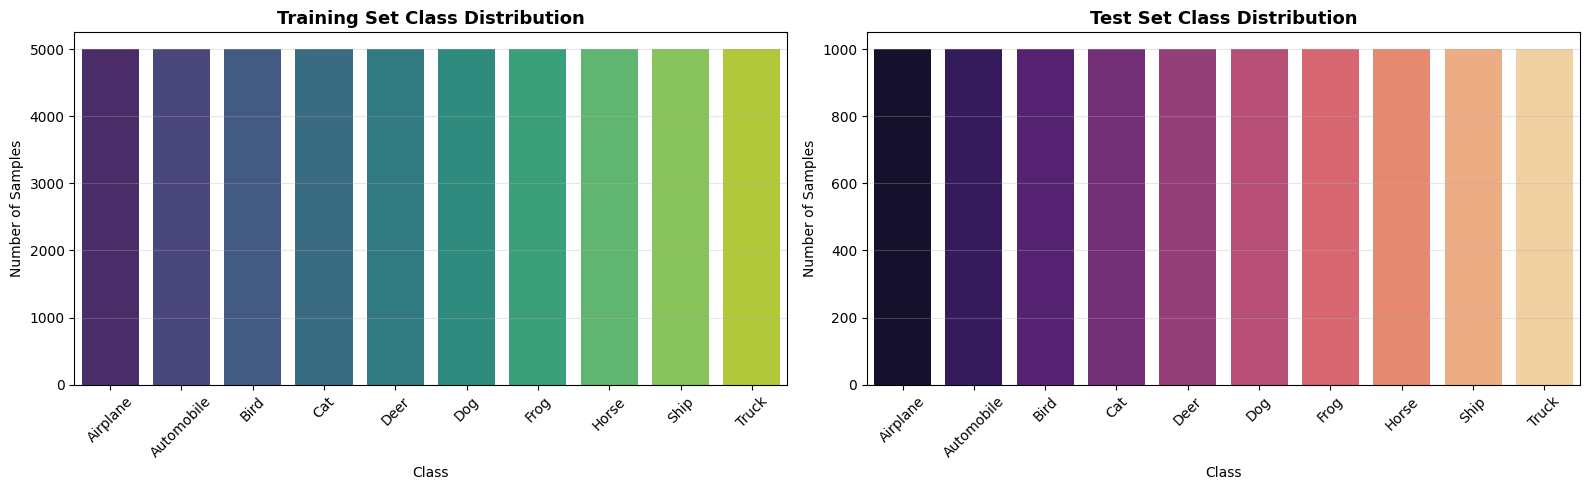

Both training and test sets are perfectly balanced across all 10 classes.


In [5]:
# ------------------------------------------------------------
# Class distribution: count plot for training and test sets
# ------------------------------------------------------------
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=CLASS_NAMES, y=train_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Training Set Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

sns.barplot(x=CLASS_NAMES, y=test_counts.values, ax=axes[1], palette="magma")
axes[1].set_title("Test Set Class Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Samples")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Both training and test sets are perfectly balanced across all 10 classes.")


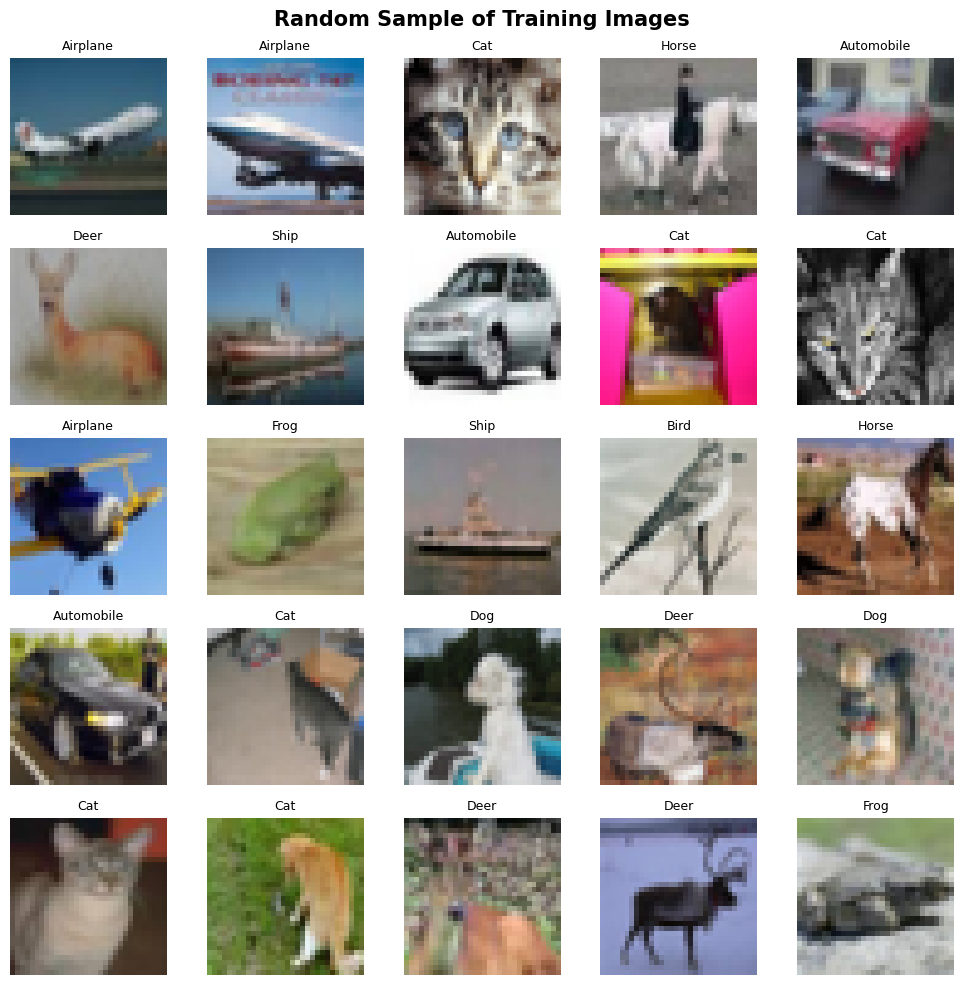

In [6]:
# ------------------------------------------------------------
# Random grid of sample images from the training set
# ------------------------------------------------------------
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
rng = np.random.default_rng(SEED)
random_indices = rng.choice(len(x_train), size=25, replace=False)

for ax, idx in zip(axes.flat, random_indices):
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[y_train[idx]], fontsize=9)
    ax.axis("off")

fig.suptitle("Random Sample of Training Images", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


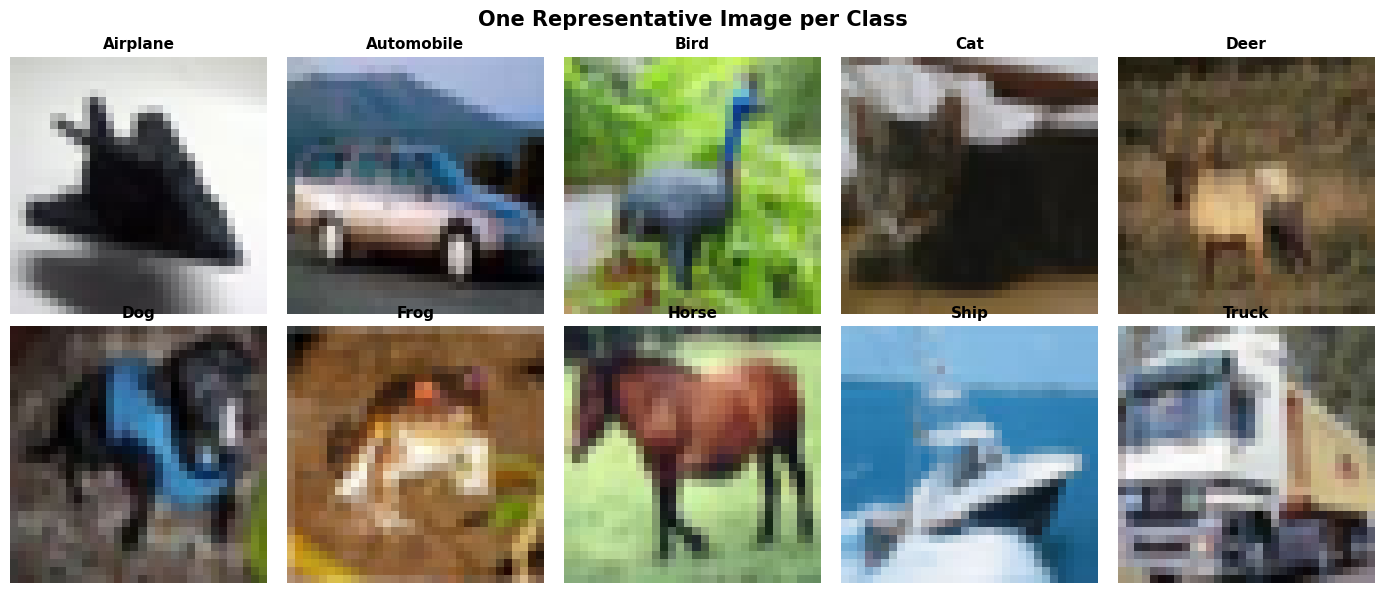

In [7]:
# ------------------------------------------------------------
# One representative image per class
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for class_idx, ax in enumerate(axes.flat):
    sample_idx = np.where(y_train == class_idx)[0][0]
    ax.imshow(x_train[sample_idx])
    ax.set_title(CLASS_NAMES[class_idx], fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle("One Representative Image per Class", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


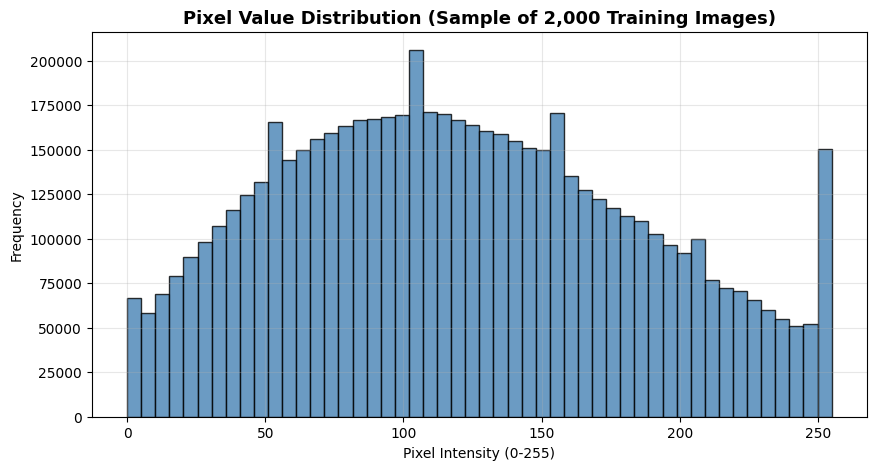

Observation: Pixel values span the full 0-255 range with a roughly uniform-to-bell-shaped spread,
confirming that per-channel normalization to [0, 1] is an appropriate preprocessing step.


In [8]:
# ------------------------------------------------------------
# Pixel value distribution (histogram) across a sample of images
# ------------------------------------------------------------
sample_pixels = x_train[:2000].astype(np.float32).ravel()

plt.figure(figsize=(10, 5))
plt.hist(sample_pixels, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
plt.title("Pixel Value Distribution (Sample of 2,000 Training Images)", fontsize=13, fontweight="bold")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

del sample_pixels
gc.collect()

print("Observation: Pixel values span the full 0-255 range with a roughly uniform-to-bell-shaped spread,")
print("confirming that per-channel normalization to [0, 1] is an appropriate preprocessing step.")


## 5. Preprocessing & `tf.data` Pipeline

**Why normalize?** Neural networks train faster and more stably when input features are on a small,
consistent scale. We rescale pixel values from the raw `[0, 255]` integer range to floating-point `[0, 1]`,
which keeps gradients well-behaved during backpropagation.

**Why `tf.data`?** Instead of loading and transforming the entire dataset into memory repeatedly, we use
the `tf.data.Dataset` API to build an efficient input pipeline that:

- **Shuffles** the training data each epoch to prevent the model from learning order-dependent patterns.
- **Batches** samples for efficient, vectorized GPU computation.
- **Caches** the dataset in memory after the first pass (since CIFAR-10 is small enough to fit) to avoid
  redundant preprocessing work.
- **Prefetches** batches so the CPU can prepare the next batch while the GPU trains on the current one,
  overlapping computation and I/O.

Labels remain as integer class indices (0-9), which is compatible with
`SparseCategoricalCrossentropy` — no one-hot encoding is required, saving memory.

In [9]:
# ------------------------------------------------------------
# Normalize pixel values to [0, 1] using float32 (memory efficient)
# ------------------------------------------------------------
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Labels are kept as sparse integer indices (no one-hot encoding needed)
y_train_sparse = y_train.astype("int32")
y_test_sparse = y_test.astype("int32")

print(f"Normalized training data range: [{x_train_norm.min():.2f}, {x_train_norm.max():.2f}]")
print(f"Normalized testing data range : [{x_test_norm.min():.2f}, {x_test_norm.max():.2f}]")

# Free the raw uint8 arrays now that normalized versions exist, to save RAM
del x_train, x_test
gc.collect()


Normalized training data range: [0.00, 1.00]
Normalized testing data range : [0.00, 1.00]


0

In [10]:
# ------------------------------------------------------------
# Build efficient tf.data pipelines: shuffle -> batch -> cache -> prefetch
# ------------------------------------------------------------
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Split a validation set from the training data (90/10 split)
val_fraction = 0.1
val_size = int(len(x_train_norm) * val_fraction)

x_val_norm = x_train_norm[:val_size]
y_val_sparse = y_train_sparse[:val_size]
x_train_final = x_train_norm[val_size:]
y_train_final = y_train_sparse[val_size:]

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train_final, y_train_final))
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val_norm, y_val_sparse))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test_norm, y_test_sparse))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

print(f"Training samples  : {len(x_train_final)}")
print(f"Validation samples: {len(x_val_norm)}")
print(f"Test samples      : {len(x_test_norm)}")
print(f"Batch size        : {BATCH_SIZE}")
print("tf.data pipelines created with shuffle -> batch -> cache -> prefetch.")


Training samples  : 45000
Validation samples: 5000
Test samples      : 10000
Batch size        : 64
tf.data pipelines created with shuffle -> batch -> cache -> prefetch.


## 6. CNN Model Architecture

We design a CNN using the **Functional API**, which offers clarity and flexibility for defining the
computational graph explicitly.

**Design choices:**

- **Convolutional blocks**: Each block applies `Conv2D -> BatchNormalization -> ReLU`, repeated twice,
  followed by `MaxPooling2D` and `Dropout`. Two convolutions per block before pooling let the network learn
  richer local features before downsampling.
- **Why Batch Normalization?** It normalizes layer activations within each mini-batch, which stabilizes and
  accelerates training, reduces sensitivity to weight initialization, and acts as a mild regularizer.
- **Why Dropout?** Randomly zeroing a fraction of activations during training prevents the network from
  co-adapting too heavily on specific neurons, reducing overfitting.
- **Why increasing filter counts (32 -> 64 -> 128)?** As spatial resolution shrinks through pooling, we
  increase the number of filters to preserve representational capacity and capture increasingly abstract,
  higher-level features.
- **GlobalAveragePooling2D** replaces a large Flatten + Dense combination before the output layer, which
  drastically reduces the parameter count and overfitting risk while retaining strong performance.
- **Softmax output**: Produces a probability distribution over the 10 mutually exclusive classes.

Before building the model, we clear the Keras backend session to ensure no leftover graph state or
variables from previous cells interfere with a fresh model definition.

In [11]:
# ------------------------------------------------------------
# Clear any previous Keras/TF session state before building the model
# ------------------------------------------------------------
K.clear_session()
gc.collect()

INPUT_SHAPE = (32, 32, 3)


def build_cnn_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """Build and return a CNN for CIFAR-10 classification using the Functional API."""
    inputs = layers.Input(shape=input_shape, name="input_image")

    # ---- Convolutional Block 1 ----
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ---- Convolutional Block 2 ----
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # ---- Convolutional Block 3 ----
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.4)(x)

    # ---- Classification Head ----
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CIFAR10_CNN")
    return model


model = build_cnn_model()
print("CNN model built successfully using the Functional API.")


CNN model built successfully using the Functional API.


## 7. Model Summary

The summary below lists every layer, its output shape, and parameter count, along with the total number of
trainable and non-trainable parameters (the latter come from `BatchNormalization` moving statistics).

In [12]:
# ------------------------------------------------------------
# Display full model summary and parameter counts
# ------------------------------------------------------------
model.summary()

trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print("\n" + "=" * 60)
print(f"Trainable parameters     : {trainable_params:,}")
print(f"Non-trainable parameters : {non_trainable_params:,}")
print(f"Total parameters         : {total_params:,}")
print("=" * 60)


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)


Trainable parameters     : 324,010
Non-trainable parameters : 1,408
Total parameters         : 325,418


## 8. Model Compilation

**Why Adam?** Adam combines the benefits of momentum and adaptive per-parameter learning rates, generally
converging faster and more reliably than plain SGD for a wide range of deep learning tasks, without
requiring extensive manual learning-rate tuning.

**Why `SparseCategoricalCrossentropy`?** Our labels are integer class indices (0-9) rather than one-hot
vectors. The "sparse" variant of categorical cross-entropy accepts integer labels directly, saving memory
and avoiding an unnecessary one-hot conversion step.

In [13]:
# ------------------------------------------------------------
# Compile the model
# ------------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

print("Model compiled with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.")


Model compiled with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.


## 9. Training Callbacks

**Why EarlyStopping?** Stops training once validation loss stops improving, preventing overfitting and
wasted computation, and restores the best-performing weights seen during training.

**Why ReduceLROnPlateau?** Automatically lowers the learning rate when validation loss plateaus, allowing
the optimizer to take smaller, more precise steps as training progresses.

**Why ModelCheckpoint?** Persists the best model (by validation accuracy) to disk during training, so the
best version is always recoverable even if later epochs overfit.

**Why TerminateOnNaN?** Immediately halts training if a NaN loss is encountered, preventing wasted GPU time
on a diverged run.

In [14]:
# ------------------------------------------------------------
# Create output directory for all artifacts
# ------------------------------------------------------------
OUTPUT_DIR = "outputs"
try:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory ready at: ./{OUTPUT_DIR}/")
except Exception as e:
    raise RuntimeError(f"Failed to create output directory: {e}")

CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "cifar10_cnn_model.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    TerminateOnNaN(),
]

print("Callbacks configured: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TerminateOnNaN.")


Output directory ready at: ./outputs/
Callbacks configured: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TerminateOnNaN.


## 10. Model Training

We train for up to 30 epochs, relying on `EarlyStopping` to halt training automatically once validation
performance stops improving. Training progress (loss and accuracy per epoch) is displayed live, and the
full history is recorded for later visualization.

In [15]:
# ------------------------------------------------------------
# Train the model, timing the full training process
# ------------------------------------------------------------
EPOCHS = 30

training_start_time = time.time()

try:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
except Exception as e:
    raise RuntimeError(f"Training failed: {e}")

training_end_time = time.time()
training_duration = training_end_time - training_start_time

print(f"\nTraining completed in {training_duration:.2f} seconds "
      f"({training_duration / 60:.2f} minutes).")


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3053 - loss: 1.9728
Epoch 1: val_accuracy improved from None to 0.49580, saving model to outputs/cifar10_cnn_model.keras

Epoch 1: finished saving model to outputs/cifar10_cnn_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.3941 - loss: 1.6760 - val_accuracy: 0.4958 - val_loss: 1.3354 - learning_rate: 0.0010
Epoch 2/30
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5509 - loss: 1.2399
Epoch 2: val_accuracy improved from 0.49580 to 0.62800, saving model to outputs/cifar10_cnn_model.keras

Epoch 2: finished saving model to outputs/cifar10_cnn_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5729 - loss: 1.1838 - val_accuracy: 0.6280 - val_loss: 1.0500 - learning_rate: 0.0010
Epoch 3/30
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6243 - loss: 1.0510
Epoch 3: val_accuracy improved from 0.62800 to 0.67500, saving model to outputs/cifar10_cnn_model.keras

Epoch 3: 

## 11. Training History Visualization

We plot training and validation accuracy/loss curves separately and combined, to inspect convergence
behavior and check for signs of overfitting (a growing gap between training and validation curves) or
underfitting (both curves plateauing at poor performance).

In [ ]:
# ------------------------------------------------------------
# Save training history to CSV for record-keeping
# ------------------------------------------------------------
history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(OUTPUT_DIR, "history.csv")
history_df.to_csv(history_csv_path, index=False)
print(f"Training history saved to: {history_csv_path}")

epochs_range = range(1, len(history_df) + 1)


In [ ]:
# ------------------------------------------------------------
# Accuracy plot (training vs validation)
# ------------------------------------------------------------
plt.figure(figsize=(9, 6), dpi=120)
plt.plot(epochs_range, history_df["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(epochs_range, history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Training vs Validation Accuracy", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_plot.png"))
plt.show()


In [ ]:
# ------------------------------------------------------------
# Loss plot (training vs validation)
# ------------------------------------------------------------
plt.figure(figsize=(9, 6), dpi=120)
plt.plot(epochs_range, history_df["loss"], label="Training Loss", linewidth=2)
plt.plot(epochs_range, history_df["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Training vs Validation Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_plot.png"))
plt.show()


In [ ]:
# ------------------------------------------------------------
# Combined accuracy + loss plot (side by side)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

axes[0].plot(epochs_range, history_df["accuracy"], label="Training Accuracy", linewidth=2)
axes[0].plot(epochs_range, history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[0].set_title("Accuracy over Epochs", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_df["loss"], label="Training Loss", linewidth=2)
axes[1].plot(epochs_range, history_df["val_loss"], label="Validation Loss", linewidth=2)
axes[1].set_title("Loss over Epochs", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "combined_plot.png"))
plt.show()


## 12. Model Evaluation on Test Set

We evaluate the trained model on the held-out test set (never seen during training or validation) to
obtain an unbiased estimate of generalization performance.

In [ ]:
# ------------------------------------------------------------
# Evaluate on the test dataset
# ------------------------------------------------------------
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\n" + "=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print("=" * 60)


## 13. Predictions on Random Test Images

We select 15 random test images, generate predictions, and display each image alongside its predicted
class, actual class, and the model's confidence for the predicted class.

In [ ]:
# ------------------------------------------------------------
# Generate predictions for the full test set (needed here and later)
# ------------------------------------------------------------
y_pred_probs = model.predict(x_test_norm, batch_size=BATCH_SIZE, verbose=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print(f"Generated predictions for {len(y_pred_labels)} test images.")


In [ ]:
# ------------------------------------------------------------
# Display 15 random predictions with confidence scores
# ------------------------------------------------------------
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(x_test_norm), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for ax, idx in zip(axes.flat, sample_indices):
    image = x_test_norm[idx]
    true_label = CLASS_NAMES[y_test_sparse[idx]]
    pred_label = CLASS_NAMES[y_pred_labels[idx]]
    confidence = y_pred_probs[idx][y_pred_labels[idx]] * 100

    ax.imshow(image)
    color = "green" if pred_label == true_label else "red"
    ax.set_title(
        f"Pred: {pred_label} ({confidence:.1f}%)\nActual: {true_label}",
        fontsize=9, color=color,
    )
    ax.axis("off")

fig.suptitle("Sample Predictions on Test Images", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 14. Confusion Matrix

The confusion matrix shows, for every true class (rows), how predictions were distributed across all
predicted classes (columns). A strong model shows a dominant diagonal with low off-diagonal values.

In [ ]:
# ------------------------------------------------------------
# Compute and plot the confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test_sparse, y_pred_labels)

plt.figure(figsize=(12, 10), dpi=120)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar_kws={"label": "Number of Samples"},
)
plt.title("Confusion Matrix - CIFAR-10 Test Set", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()


## 15. Classification Report

The classification report provides per-class **precision**, **recall**, **F1-score**, and **support**
(number of true samples per class), giving a more granular view of performance than overall accuracy alone.

In [ ]:
# ------------------------------------------------------------
# Generate and save the classification report
# ------------------------------------------------------------
report_str = classification_report(y_test_sparse, y_pred_labels, target_names=CLASS_NAMES, digits=4)
print(report_str)

report_path = os.path.join(OUTPUT_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write("CIFAR-10 CNN Classification Report\n")
    f.write("=" * 60 + "\n")
    f.write(report_str)

print(f"\nClassification report saved to: {report_path}")


## 16. Misclassified Images Analysis

Inspecting misclassified samples often reveals informative failure modes — for example, visually similar
classes (cat vs. dog, automobile vs. truck) or genuinely ambiguous images.

In [ ]:
# ------------------------------------------------------------
# Find and display misclassified images
# ------------------------------------------------------------
misclassified_indices = np.where(y_pred_labels != y_test_sparse)[0]
print(f"Total misclassified images: {len(misclassified_indices)} out of {len(y_test_sparse)} "
      f"({len(misclassified_indices) / len(y_test_sparse) * 100:.2f}%)")

num_to_show = min(15, len(misclassified_indices))
rng = np.random.default_rng(SEED)
chosen_misclassified = rng.choice(misclassified_indices, size=num_to_show, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for ax, idx in zip(axes.flat, chosen_misclassified):
    image = x_test_norm[idx]
    true_label = CLASS_NAMES[y_test_sparse[idx]]
    pred_label = CLASS_NAMES[y_pred_labels[idx]]

    ax.imshow(image)
    ax.set_title(f"Actual: {true_label}\nPredicted: {pred_label}", fontsize=9, color="red")
    ax.axis("off")

fig.suptitle("Sample Misclassified Test Images", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 17. Final Model Saving & Output Summary

The best model (already checkpointed during training via `ModelCheckpoint`) is re-saved explicitly here to
guarantee a final `cifar10_cnn_model.keras` file exists in the `outputs/` directory, alongside all other
generated artifacts (plots, history, confusion matrix image, and classification report).

In [ ]:
# ------------------------------------------------------------
# Explicitly save the final model (redundant safety net alongside ModelCheckpoint)
# ------------------------------------------------------------
try:
    model.save(CHECKPOINT_PATH)
    print(f"Model saved successfully to: {CHECKPOINT_PATH}")
except Exception as e:
    raise RuntimeError(f"Failed to save model: {e}")

print("\nFiles in output directory:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  - {fname} ({size_kb:.1f} KB)")


## 18. Final Summary & Performance Report

The final cell reports total execution time, cleans up memory, and prints a completion summary confirming
that the model, history, plots, confusion matrix, and classification report were all saved successfully.

In [27]:
# ------------------------------------------------------------
# Final cleanup and summary report
# ------------------------------------------------------------
notebook_end_time = time.time()
total_runtime = notebook_end_time - training_start_time

# Clean up large in-memory objects no longer needed
del y_pred_probs
gc.collect()

print("=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)
print(f"Model saved at        : {os.path.abspath(CHECKPOINT_PATH)}")
print(f"Output directory      : {os.path.abspath(OUTPUT_DIR)}/")
print(f"Test Accuracy         : {test_accuracy * 100:.2f}%")
print(f"Test Loss             : {test_loss:.4f}")
print(f"Total Training Time   : {training_duration:.2f} seconds ({training_duration / 60:.2f} min)")
print(f"Total Notebook Runtime: {total_runtime:.2f} seconds ({total_runtime / 60:.2f} min)")
print("=" * 60)


PROJECT COMPLETED SUCCESSFULLY
Model saved at        : /content/outputs/cifar10_cnn_model.keras
Output directory      : /content/outputs/
Test Accuracy         : 85.96%
Test Loss             : 0.4427
Total Training Time   : 537.33 seconds (8.96 min)
Total Notebook Runtime: 546.62 seconds (9.11 min)
